### **PROJECT: HR — Employee Attrition**
---

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,classification_report,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')


### **Load Dataset**
---

In [3]:
df = pd.read_csv('HR-dataset.csv')
print(df.shape)
df.head(2)

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7


### **EDA**
---

In [4]:
print("=== Data Info ===")
# print(df.info())

print("=== Check Missing Value ===")
missing = df.isnull().sum() 
print(missing[missing > 0] if missing.sum() > 0 else "No missing value")

=== Data Info ===
=== Check Missing Value ===
No missing value


In [5]:
print("=== Target : Attrition ===")
print(df['Attrition'].value_counts())
print()

ratio = (df['Attrition'] == 'Yes').sum() / len(df) * 100
print(f"Attrition Ratio: {ratio:.1f}%")

=== Target : Attrition ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Ratio: 16.1%


### **Visualization**
---

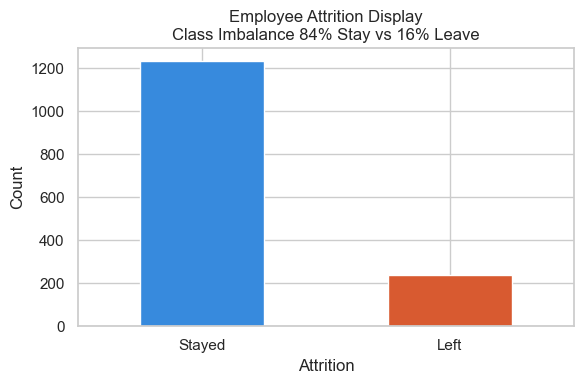

In [6]:
sns.set_theme(style='whitegrid',palette='muted')
colors = ['#378ADD', '#D85A30']

fig, ax = plt.subplots(figsize=(6,4))
df['Attrition'].value_counts().plot(
    kind='bar',ax=ax,
    color=colors,edgecolor='white',width=0.5
)
ax.set_title("Employee Attrition Display\n"
             "Class Imbalance 84% Stay vs 16% Leave",fontsize=12)
ax.set_xticklabels(["Stayed","Left"],rotation=0)
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig('01_target_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

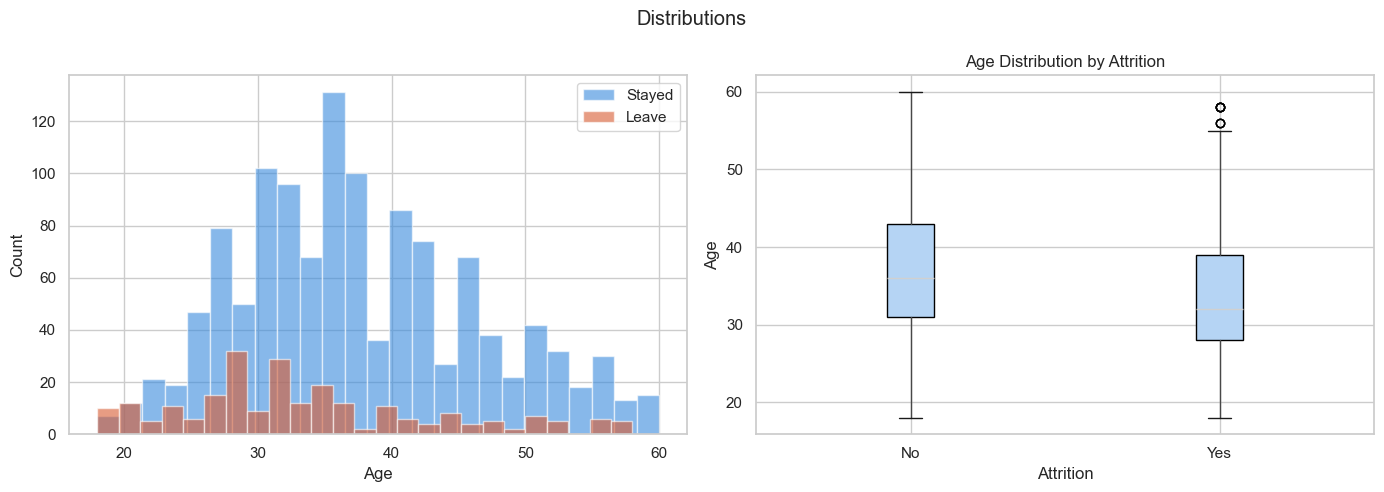

In [7]:
# Age vs Attrition

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[df['Attrition']== 'No']['Age'],alpha=0.6,bins=25,color='#378ADD',label='Stayed')
axes[0].hist(df[df['Attrition']== 'Yes']['Age'],alpha=0.6,bins=25,color='#D85A30',label='Leave')
axes[0].set_label("Age vs Attrition")
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

df.boxplot(column='Age',by='Attrition',ax=axes[1],
           patch_artist=True, boxprops=dict(facecolor='#B5D4F4'))
axes[1].set_title('Age Distribution by Attrition')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Age')
plt.suptitle('Distributions')
plt.tight_layout()
plt.savefig('02_age_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

In [8]:
print("=== Age Insights ===")
print(f"Left avg. age: {df[df['Attrition'] == 'Yes']['Age'].mean():.1f}")
print(f"Stayed avg. age:  {df[df['Attrition'] == 'No']['Age'].mean():.1f}")

=== Age Insights ===
Left avg. age: 33.6
Stayed avg. age:  37.6


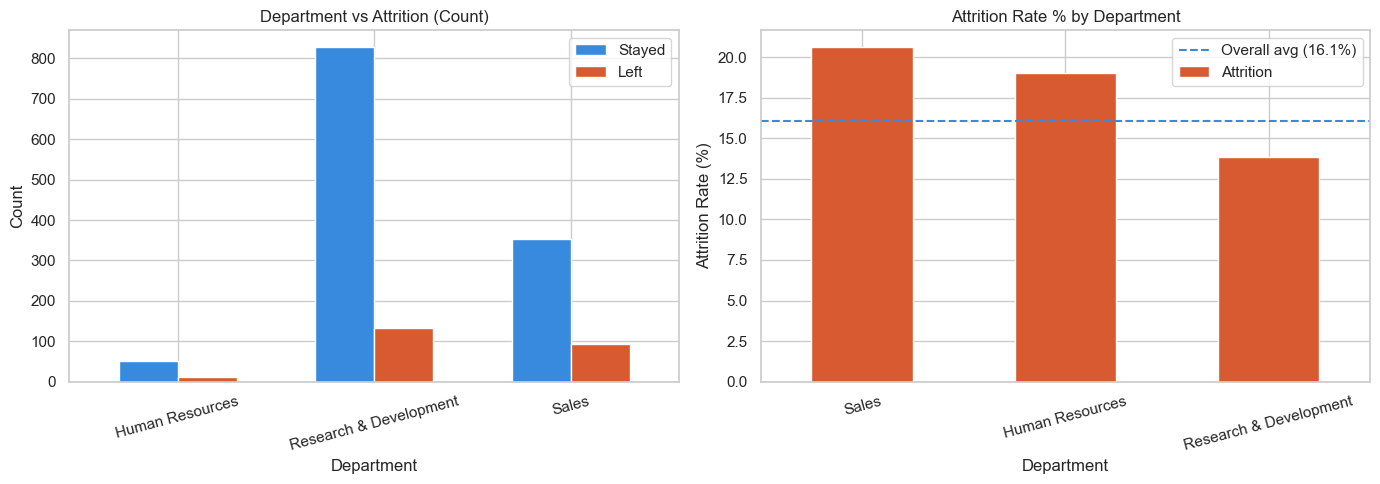

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_attr = df.groupby(['Department','Attrition']).size().unstack()
dept_attr.plot(kind='bar',ax=axes[0],color=colors,edgecolor='white',width=0.6)
axes[0].set_title('Department vs Attrition (Count)')
axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=15)
axes[0].set_ylabel('Count')
axes[0].legend(['Stayed','Left'])

# Graph 2
dept_pct = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean() * 100
).sort_values(ascending=False)
dept_pct.plot(kind='bar', ax=axes[1],
              color='#D85A30', edgecolor='white', width=0.5)
axes[1].set_title('Attrition Rate % by Department')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].axhline(y=16.1, color='#378ADD',
                linestyle='--', label='Overall avg (16.1%)')
axes[1].legend()
plt.tight_layout()
plt.savefig("03_department_attrition.png",dpi=150,bbox_inches='tight')
plt.show()

In [10]:
print("=== Depart. Insights ===")
print(dept_pct.round(1))

=== Depart. Insights ===
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64


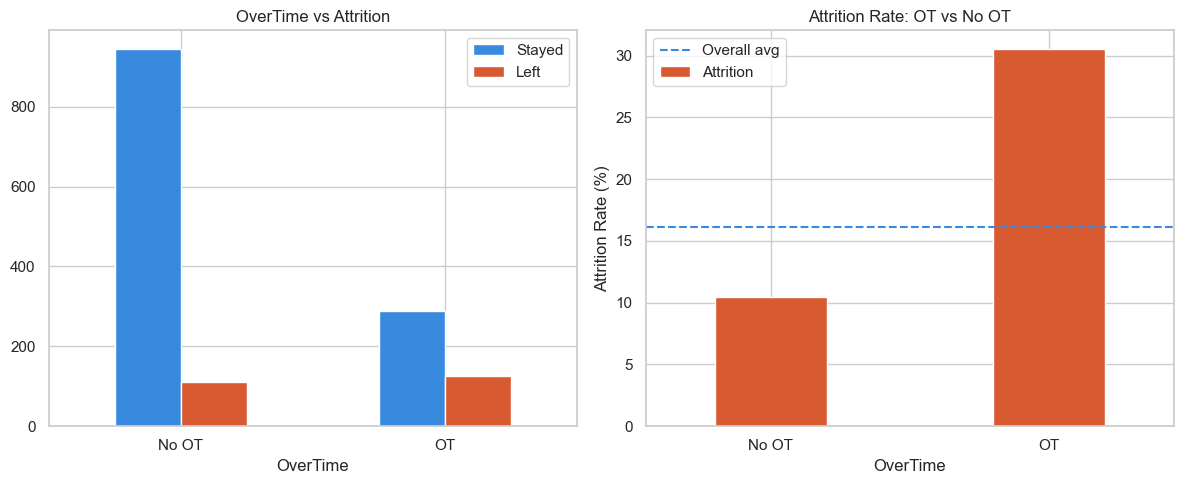

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ot = df.groupby(['OverTime', 'Attrition']).size().unstack()
ot.plot(kind='bar', ax=axes[0], color=colors,
        edgecolor='white', width=0.5)
axes[0].set_title('OverTime vs Attrition')
axes[0].set_xticklabels(['No OT', 'OT'], rotation=0)
axes[0].legend(['Stayed', 'Left'])

# Rate
ot_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').mean() * 100
)
ot_rate.plot(kind='bar', ax=axes[1],
             color='#D85A30', edgecolor='white', width=0.4)
axes[1].set_title('Attrition Rate: OT vs No OT')
axes[1].set_xticklabels(['No OT', 'OT'], rotation=0)
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].axhline(y=16.1, color='#378ADD',
                linestyle='--', label='Overall avg')
axes[1].legend()
plt.tight_layout()
plt.savefig('04_OT_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

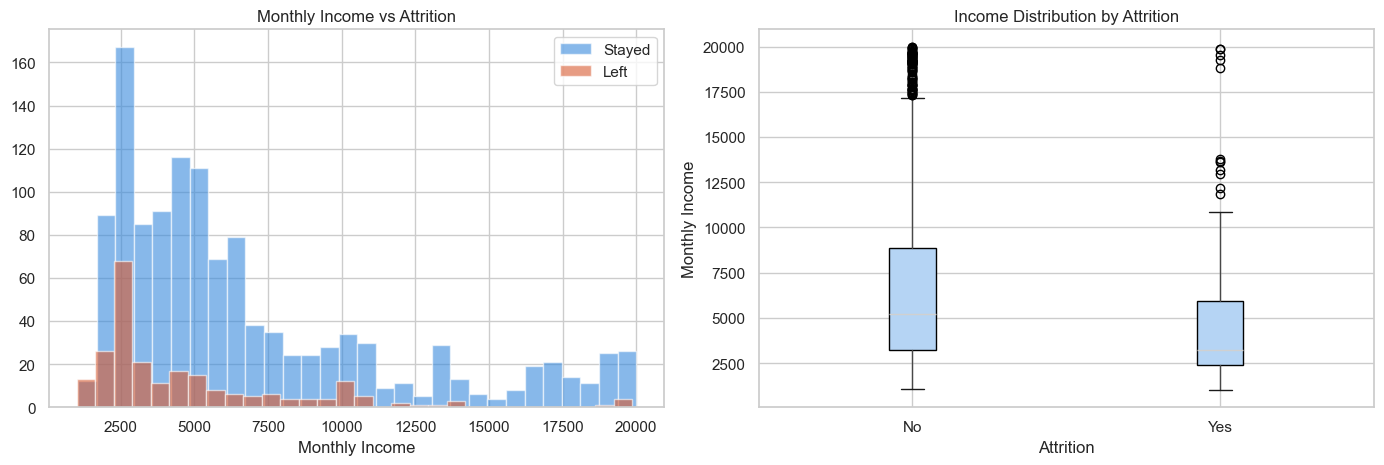

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Attrition'] == 'No']['MonthlyIncome'],alpha=0.6, bins=30, color='#378ADD', label='Stayed')
axes[0].hist(df[df['Attrition']=='Yes']['MonthlyIncome'],
             alpha=0.6, bins=30, color='#D85A30', label='Left')
axes[0].set_title('Monthly Income vs Attrition')
axes[0].set_xlabel('Monthly Income')
axes[0].legend()

# BoxPlot
df.boxplot(column='MonthlyIncome', by='Attrition',
           ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4'))
axes[1].set_title('Income Distribution by Attrition')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Monthly Income')
plt.suptitle('')

plt.tight_layout()
plt.savefig('05_income_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

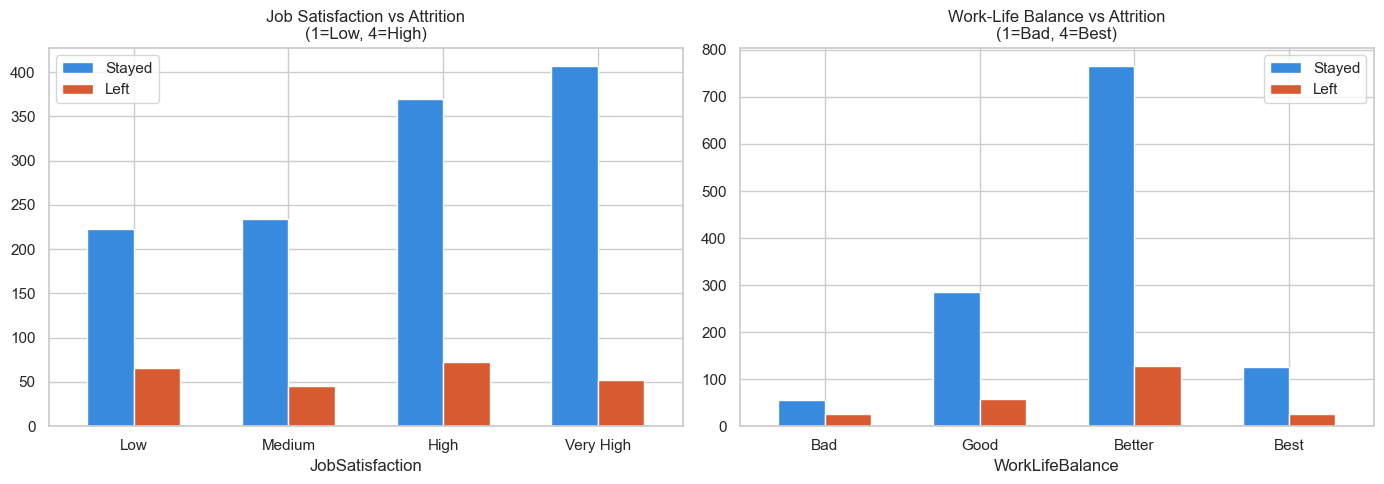

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

js = df.groupby(['JobSatisfaction','Attrition']).size().unstack()
js.plot(kind='bar',ax=axes[0],color=colors, edgecolor='white',width=0.6)
axes[0].set_title('Job Satisfaction vs Attrition\n(1=Low, 4=High)')
axes[0].set_xticklabels(['Low', 'Medium', 'High', 'Very High'],rotation=0)
axes[0].legend(['Stayed', 'Left'])

# work life balance
wl = df.groupby(['WorkLifeBalance','Attrition']).size().unstack()
wl.plot(kind='bar',ax=axes[1], color=colors, edgecolor='white',width=0.6)
axes[1].set_title('Work-Life Balance vs Attrition\n(1=Bad, 4=Best)')
axes[1].set_xticklabels(['Bad', 'Good', 'Better', 'Best'],
                          rotation=0)
axes[1].legend(['Stayed', 'Left'])

plt.tight_layout()
plt.savefig('06_satisfaction_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

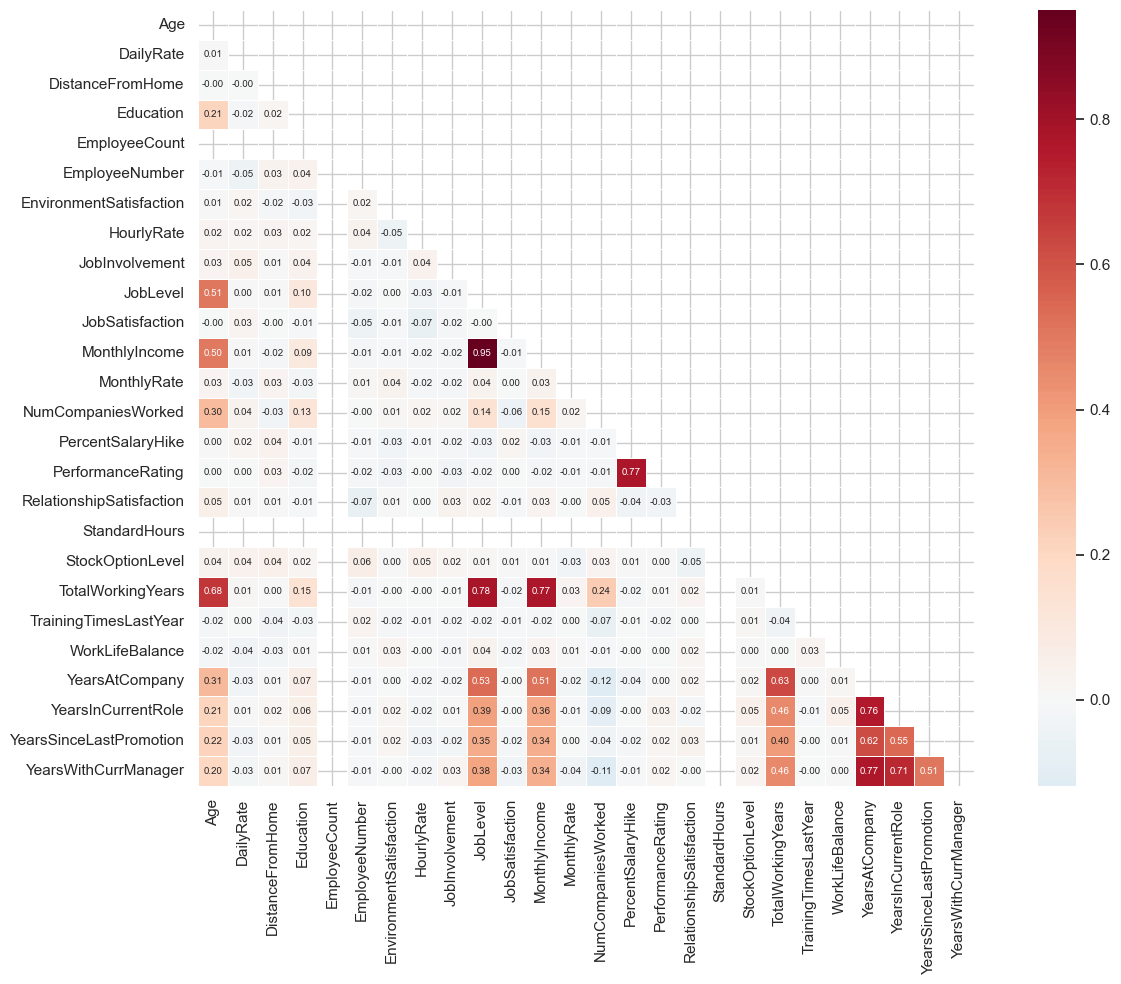

In [14]:
plt.figure(figsize=(14, 10))
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            square=True, linewidths=0.5,
            annot_kws={'size': 7})
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

### **Data Preprocessing**
---

In [15]:
print("=== Column Types ===")
# print(df.dtypes)
print(f"\nTotal Columns: {df.shape[1]}")
print(f"Numerical Columns: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical Columns: {df.select_dtypes(include=['object']).shape[1]}")
print(30*"=")
cat_col = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_col:
    print(f"{col:20} → {df[col].unique().tolist()}")

=== Column Types ===

Total Columns: 35
Numerical Columns: 26
Categorical Columns: 9
Attrition            → ['Yes', 'No']
BusinessTravel       → ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Department           → ['Sales', 'Research & Development', 'Human Resources']
EducationField       → ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
Gender               → ['Female', 'Male']
JobRole              → ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
MaritalStatus        → ['Single', 'Married', 'Divorced']
Over18               → ['Y']
OverTime             → ['Yes', 'No']


In [16]:
df['BusinessTravel'].value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

In [17]:
# Drop Useless Columns

cols_to_drop = ['EmployeeNumber', 'Over18',
                'StandardHours', 'EmployeeCount']

df = df.drop(columns=cols_to_drop)

### **Train / Test Split**
---

In [18]:
X = df.drop('Attrition',axis=1)
y = df['Attrition']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [20]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
y_test.shape

(294,)

In [21]:
ohe_cols = ['BusinessTravel', 'Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer(transformers=[
    ('tnfs1',OneHotEncoder(drop='first',sparse_output=False),ohe_cols)
],remainder='passthrough')

### **Model Training + Evaluation**
---

In [23]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train,y_train)
dummy_acc = accuracy_score(y_test,dummy.predict(X_test))

print(f"Dummy Accuracy: {dummy_acc:.2%}")

Dummy Accuracy: 84.01%


### **PipeLine**
---

In [24]:
# Decision Tree
from sklearn.pipeline import Pipeline

dt_pipe = Pipeline([
    ('preprocess',transformer),
    ('dt_model',DecisionTreeClassifier(
        max_depth=4,
        random_state=42,
        class_weight='balanced'
    ))
])
dt_pipe.fit(X_train,y_train)
dt_pred = dt_pipe.predict(X_test)

print("=== Decision Tree Results ===")
print(f"Training Accuracy: {accuracy_score(y_train,dt_pipe.predict(X_train)):.2%}")
print(f"Testing Accuracy: {accuracy_score(y_test,dt_pred):.2%}")
print("\n=== Classification Report ===")
print(classification_report(y_test,dt_pred,target_names=['Stayed','Left']))

=== Decision Tree Results ===
Training Accuracy: 78.74%
Testing Accuracy: 71.43%

=== Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.89      0.76      0.82       247
        Left       0.28      0.49      0.35        47

    accuracy                           0.71       294
   macro avg       0.58      0.62      0.59       294
weighted avg       0.79      0.71      0.74       294



In [25]:
# Random Forest

rf_pipe = Pipeline([
    ('preprocess',transformer),
    ('rf_model',RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnfs1', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [26]:
rf_pred = rf_pipe.predict(X_test)
print(f"Training Accuracy: {accuracy_score(y_train,rf_pipe.predict(X_train)):.2%}")
print(f"Testing Accuracy: {accuracy_score(y_test,rf_pipe.predict(X_test)):.2%}")

Training Accuracy: 97.79%
Testing Accuracy: 83.67%


### **Detailed Evaluation**
---

              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.91       247
        Left       0.48      0.34      0.40        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.65       294
weighted avg       0.82      0.84      0.82       294



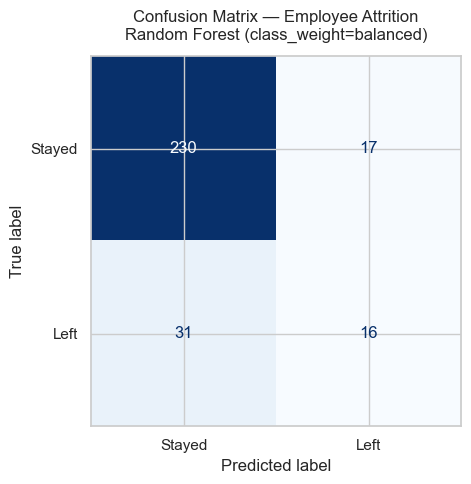

Stayed Employees: 230
Left Employees: 16
Wrong Stayed prediction: 31
Wrong Left prediction:  17


In [27]:
print(classification_report(y_test,rf_pred,target_names=['Stayed','Left']))
cm= confusion_matrix(y_test,rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stayed','Left'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax,colorbar=False,cmap='Blues')
ax.set_title('Confusion Matrix — Employee Attrition\n'
             'Random Forest (class_weight=balanced)', pad=12)
plt.tight_layout()
plt.savefig('08_confusion_matrix_rf.png',
            dpi=150, bbox_inches='tight')
plt.show()
tn,fp,fn,tp = cm.ravel()
print(f"Stayed Employees: {tn}")
print(f"Left Employees: {tp}")
print(f"Wrong Stayed prediction: {fn}")
print(f"Wrong Left prediction:  {fp}")

### **Models Comparison**
---

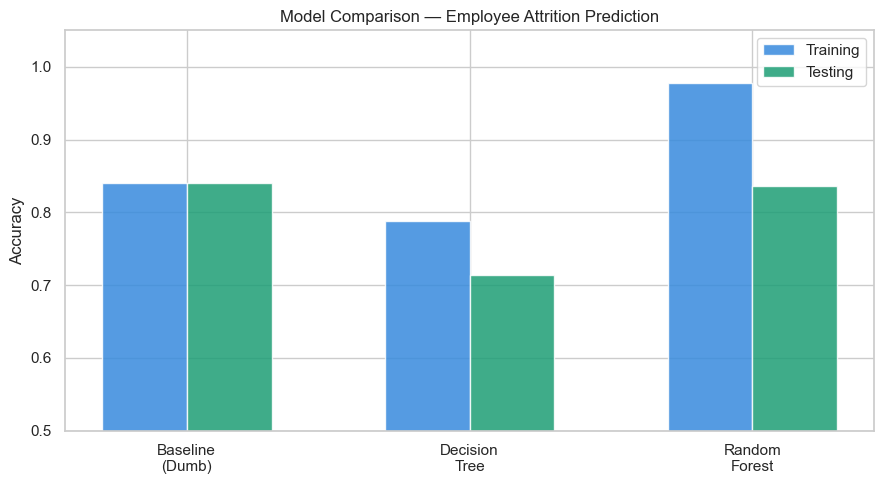

[0.8401360544217688, 0.7142857142857143, 0.8367346938775511]


In [28]:
models_names = ['Baseline\n(Dumb)', 'Decision\nTree', 'Random\nForest']

train_acc = [dummy_acc,
             accuracy_score(y_train,dt_pipe.predict(X_train)),
             accuracy_score(y_train,rf_pipe.predict(X_train))]
test_acc = [dummy_acc,
             accuracy_score(y_test,dt_pred),
             accuracy_score(y_test,rf_pred)]
x = np.arange(len(models_names))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x-width/2,train_acc,width,label="Training",color='#378ADD', alpha=0.85)
bars2 = ax.bar(x+width/2,test_acc,width,label="Testing",color='#1D9E75', alpha=0.85)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Employee Attrition Prediction',
             fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(test_acc)

In [29]:
print("=== MODEL COMPARISON ===")
print(f"Baseline:       {dummy_acc:.2%}")
print(f"Decision Tree:  {accuracy_score(y_test, dt_pred):.2%}")
print(f"Random Forest:  {accuracy_score(y_test, rf_pred):.2%}")
print()
print("=== CLASSIFICATION REPORT (RF) ===")
print(classification_report(y_test, rf_pred,
      target_names=['Stayed', 'Left']))

=== MODEL COMPARISON ===
Baseline:       84.01%
Decision Tree:  71.43%
Random Forest:  83.67%

=== CLASSIFICATION REPORT (RF) ===
              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.91       247
        Left       0.48      0.34      0.40        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.65       294
weighted avg       0.82      0.84      0.82       294



### **Balanced Data Model**
---

In [46]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

rf_balanced = ImbPipeline(steps=[
    ('preprocess',transformer),
    ('balance',SMOTETomek(random_state=42)),
    ('rf_bal_model',RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_balanced.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('balance', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnfs1', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The give

In [47]:
rf_bal_pred = rf_balanced.predict(X_test)

In [48]:
print("=== Before Balancing ===")
print()
print(f"Accuracy: {accuracy_score(y_test,rf_pred):.2%}")
print(f"Recall score: {recall_score(y_test,rf_pred):.2%}")
print(f"F1 score: {f1_score(y_test,rf_pred):.2%}")
print()
print("=== After Balancing ===")
print()
print(f"Accuracy: {accuracy_score(y_test,rf_bal_pred):.2%}")
print(f"Recall score: {recall_score(y_test,rf_bal_pred):.2%}")
print(f"F1 score: {f1_score(y_test,rf_bal_pred):.2%}")

=== Before Balancing ===

Accuracy: 83.67%
Recall score: 34.04%
F1 score: 40.00%

=== After Balancing ===

Accuracy: 85.37%
Recall score: 19.15%
F1 score: 29.51%


### **Model Save**
---

In [49]:
import pickle

with open('employee_attr.pkl','wb') as f:
    pickle.dump(rf_pipe,f)

In [51]:
with open('employee_attr.pkl','rb') as f:
    saved = pickle.load(f)